In [29]:
import pandas as pd
import numpy as np
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt 
import time

# Análisis Exploratorio de Datos (EDA): Demografía y Rating en el Ajedrez

In [30]:
df = pd.read_parquet('../data/processed/fide_players_active.parquet')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 437166 entries, 0 to 437165
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   fideid        437166 non-null  string  
 1   name          437166 non-null  string  
 2   country       437166 non-null  category
 3   sex           437166 non-null  category
 4   title         437166 non-null  category
 5   w_title       437166 non-null  category
 6   o_title       437166 non-null  category
 7   rating        219417 non-null  Int64   
 8   rapid_rating  324549 non-null  Int64   
 9   blitz_rating  203133 non-null  Int64   
 10  birthday      437166 non-null  Int64   
 11  flag          437166 non-null  category
 12  es_activo     437166 non-null  bool    
 13  edad          437166 non-null  Int64   
dtypes: Int64(5), bool(1), category(6), string(2)
memory usage: 39.8 MB


In [43]:
df.describe()

,rating,rapid_rating,blitz_rating,birthday,edad
count,219417.0,324549.0,203133.0,437166.0,437166.0
mean,1734.254137,1657.180201,1703.732402,1994.075706,31.924294
std,223.856323,200.865953,216.166838,19.752018,19.752018
min,1400.0,1400.0,1400.0,1931.0,4.0
25%,1556.0,1501.0,1533.0,1980.0,16.0
50%,1700.0,1611.0,1664.0,2001.0,25.0
75%,1873.0,1768.0,1833.0,2010.0,46.0
max,2823.0,2803.0,2860.0,2022.0,95.0


- Tabla que indica los estadisticos de la poblacion completa de jugadores activos registrados en la FIDE.

In [83]:
df[df["sex"] == "F"].describe()

,rating,rapid_rating,blitz_rating,birthday,edad
count,23620.0,31894.0,21051.0,42197.0,42197.0
mean,1631.36486,1581.759296,1613.858629,2004.61201,21.38799
std,196.673346,169.015086,181.770323,13.786865,13.786865
min,1400.0,1400.0,1400.0,1931.0,4.0
25%,1483.0,1460.0,1475.0,2003.0,13.0
50%,1572.0,1528.0,1561.0,2010.0,16.0
75%,1730.0,1650.0,1708.0,2013.0,23.0
max,2596.0,2529.0,2521.0,2022.0,95.0


- Tabla que indica los estadisticos de la poblacion completa de jugadores mujeres activas registradas en la FIDE.

In [95]:
df[df["sex"] == "M"].describe()

,rating,rapid_rating,blitz_rating,birthday,edad
count,195797.0,292655.0,182082.0,394969.0,394969.0
mean,1746.6662,1665.399689,1714.122956,1992.950047,33.049953
std,223.740325,202.34541,217.414239,19.959696,19.959696
min,1400.0,1400.0,1400.0,1931.0,4.0
25%,1570.0,1508.0,1543.0,1978.0,16.0
50%,1715.0,1622.0,1677.0,2000.0,26.0
75%,1885.0,1778.0,1844.0,2010.0,48.0
max,2823.0,2803.0,2860.0,2022.0,95.0


- Tabla que indica los estadisticos de la poblacion completa de jugadores hombres activos registrados en la FIDE.

## 1. Análisis Demográfico y de Elo

### 1.1. Analisis global por Sexo

In [96]:
df_genero = df['sex'].value_counts().reset_index()

df_genero['proporcion'] = df_genero['count'] / df_genero['count'].sum() 
df_genero['porcentaje'] = np.round(df_genero['proporcion'], 2) * 100

df_genero

,sex,count,proporcion,porcentaje
0,M,394969,0.903476,90.0
1,F,42197,0.096524,10.0


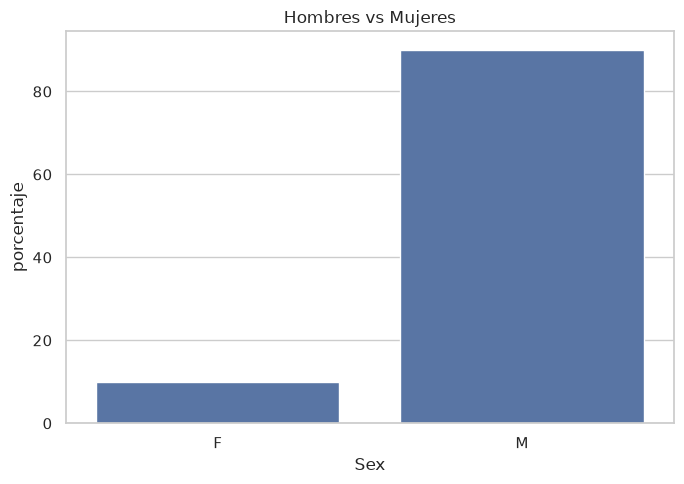

In [97]:
fig, ax = plt.subplots(figsize=(7,5))

sns.barplot(x=df_genero['sex'], y=df_genero['porcentaje'])
ax.set_title('Hombres vs Mujeres')
ax.set_xlabel('Sex')
ax.set_ylabel('porcentaje')

plt.tight_layout()
plt.show()

El 90% de los jugadores de ajedrez en todo el mundo son hombres, mientras que el 10% son mujeres. Esto indica que el ajedrez es un juego mayormente jugado por hombres, por lo que tenemos datos insuficientes para comparar ambas poblaciones. El modelo debe contemplar esto y no presentar sesgos en torno al género.

### 1.2. Proporción por sexo según Federación (FED)

- Tabla que muestra la proporcion de jugadores mujeres y hombres que tiene la federacion con respecto al total global. 

In [98]:

df_genero_FED = (
    pd.crosstab(index=df['country'], columns=df['sex'])
    .assign(total=lambda x: x.sum(axis=1))   
    .sort_values(by='total', ascending=False) 
    .reset_index()                            
)

df_genero_FED_global = df_genero_FED.copy()

df_genero_FED_global['h_F'] = df_genero_FED_global['F'] / df_genero_FED_global['total'].sum()
df_genero_FED_global['h_M'] = df_genero_FED_global['M'] / df_genero_FED_global['total'].sum()
df_genero_FED_global['h_F%'] = df_genero_FED_global['h_F'] * 100
df_genero_FED_global['h_M%'] = df_genero_FED_global['h_M'] * 100

df_genero_FED_global.head()


sex,country,F,M,total,h_F,h_M,h_F%,h_M%
0,IND,4332,30649,34981,0.009909,0.070108,0.990928,7.010838
1,RUS,4798,29506,34304,0.010975,0.067494,1.097524,6.749381
2,FRA,2420,29861,32281,0.005536,0.068306,0.553565,6.830586
3,ESP,1284,21508,22792,0.002937,0.049199,0.293710,4.919870
4,IRI,1674,18563,20237,0.003829,0.042462,0.382921,4.246213


In [99]:
print(f' [%] Total de mujeres: {df_genero_FED_global['h_F%'].sum()}')
print(f' [%] Total de hombres: {df_genero_FED_global['h_M%'].sum()}')

 [%] Total de mujeres: 9.652397487453278
 [%] Total de hombres: 90.34760251254673


- Tabla que muestra la proporcion de jugadores mujeres y hombres con respecto al total de jugadores de su Federacion. 

In [100]:


df_genero_FED['h_F'] = df_genero_FED['F'] / df_genero_FED['total']
df_genero_FED['h_M'] = df_genero_FED['M'] / df_genero_FED['total']
df_genero_FED['h_F%'] = np.round(df_genero_FED['h_F'],2) * 100
df_genero_FED['h_M%'] = np.round(df_genero_FED['h_M'],2) * 100

df_genero_FED.head()

sex,country,F,M,total,h_F,h_M,h_F%,h_M%
0,IND,4332,30649,34981,0.123839,0.876161,12.0,88.0
1,RUS,4798,29506,34304,0.139867,0.860133,14.0,86.0
2,FRA,2420,29861,32281,0.074967,0.925033,7.0,93.0
3,ESP,1284,21508,22792,0.056336,0.943664,6.0,94.0
4,IRI,1674,18563,20237,0.082720,0.917280,8.0,92.0


### 1.3. Comparativa de rating global por sexo

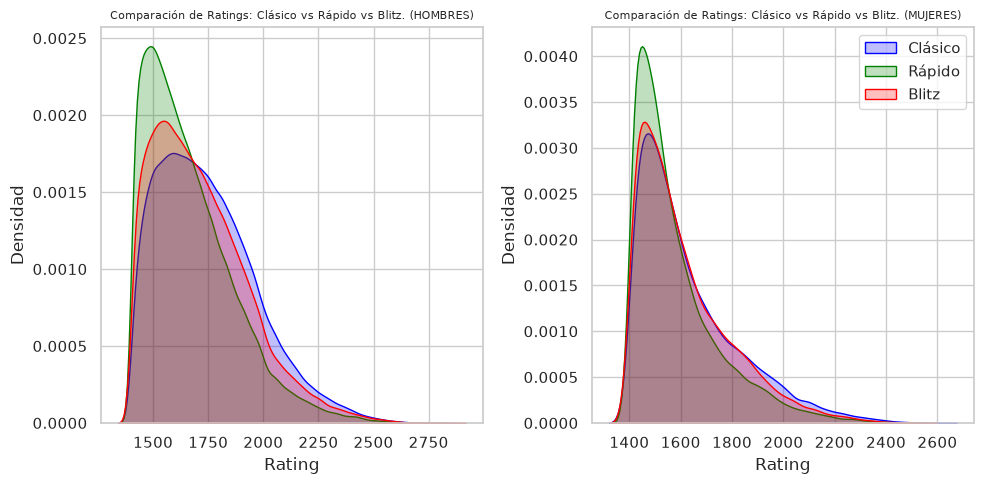

In [101]:

df_hombres = df[df['sex'] == 'M']
df_mujeres = df[df['sex'] == 'F']

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1,2, figsize=(10,5))


sns.kdeplot(df_hombres[df_hombres['rating'] > 0]['rating'], fill=True, color='blue', label='Clásico', ax=ax[0])
sns.kdeplot(df_hombres[df_hombres['rapid_rating'] > 0]['rapid_rating'], fill=True, color='green', label='Rápido', ax=ax[0])
sns.kdeplot(df_hombres[df_hombres['blitz_rating'] > 0]['blitz_rating'], fill=True, color='red', label='Blitz', ax=ax[0])

ax[0].set_title('Comparación de Ratings: Clásico vs Rápido vs Blitz. (HOMBRES)', fontsize=8)
ax[0].set_xlabel('Rating', fontsize=12)
ax[0].set_ylabel('Densidad', fontsize=12)


sns.kdeplot(df_mujeres[df_mujeres['rating'] > 0]['rating'], fill=True, color='blue', label='Clásico', ax=ax[1])
sns.kdeplot(df_mujeres[df_mujeres['rapid_rating'] > 0]['rapid_rating'], fill=True, color='green', label='Rápido',ax=ax[1])
sns.kdeplot(df_mujeres[df_mujeres['blitz_rating'] > 0]['blitz_rating'], fill=True, color='red', label='Blitz', ax=ax[1])

ax[1].set_title('Comparación de Ratings: Clásico vs Rápido vs Blitz. (MUJERES)', fontsize=8)
ax[1].set_xlabel('Rating', fontsize=12)
ax[1].set_ylabel('Densidad', fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()

### 1.4. Analisis por categorias juveniles

In [ ]:
reglas_ajedrez = {
    "Sub 8":  (df["edad"] > 0) & (df["edad"] < 8),
    "Sub 10": (df["edad"] >= 8) & (df["edad"] < 10),
    "Sub 12": (df["edad"] >= 10) & (df["edad"] < 12),
    "Sub 14": (df["edad"] >= 12) & (df["edad"] < 14),
    "Sub 16": (df["edad"] >= 14) & (df["edad"] < 16),
    "Sub 18": (df["edad"] >= 16) & (df["edad"] < 18),
    "Sub 20": (df["edad"] >= 18) & (df["edad"] < 20),
    "Absoluta": df["edad"] >= 20,
}



df["categoria"] = np.select(
    list(reglas_ajedrez.values()), list(reglas_ajedrez.keys()), default="Sin Categoría"
)


df_categorias = df['categoria'].value_counts().reset_index()



df_categorias['proporcion'] = df_categorias['count'] / df_categorias['count'].sum() 
df_categorias['porcentaje'] = np.round(df_categorias['proporcion'], 4) * 100
df_categorias



,categoria,count,proporcion,porcentaje
0,Absoluta,266043,0.608563,60.86
1,Sub 16,40324,0.092240,9.22
2,Sub 18,36643,0.083819,8.38
3,Sub 14,34578,0.079096,7.91
4,Sub 20,28362,0.064877,6.49
5,Sub 12,22110,0.050576,5.06
6,Sub 10,8093,0.018512,1.85
7,Sub 8,1013,0.002317,0.23


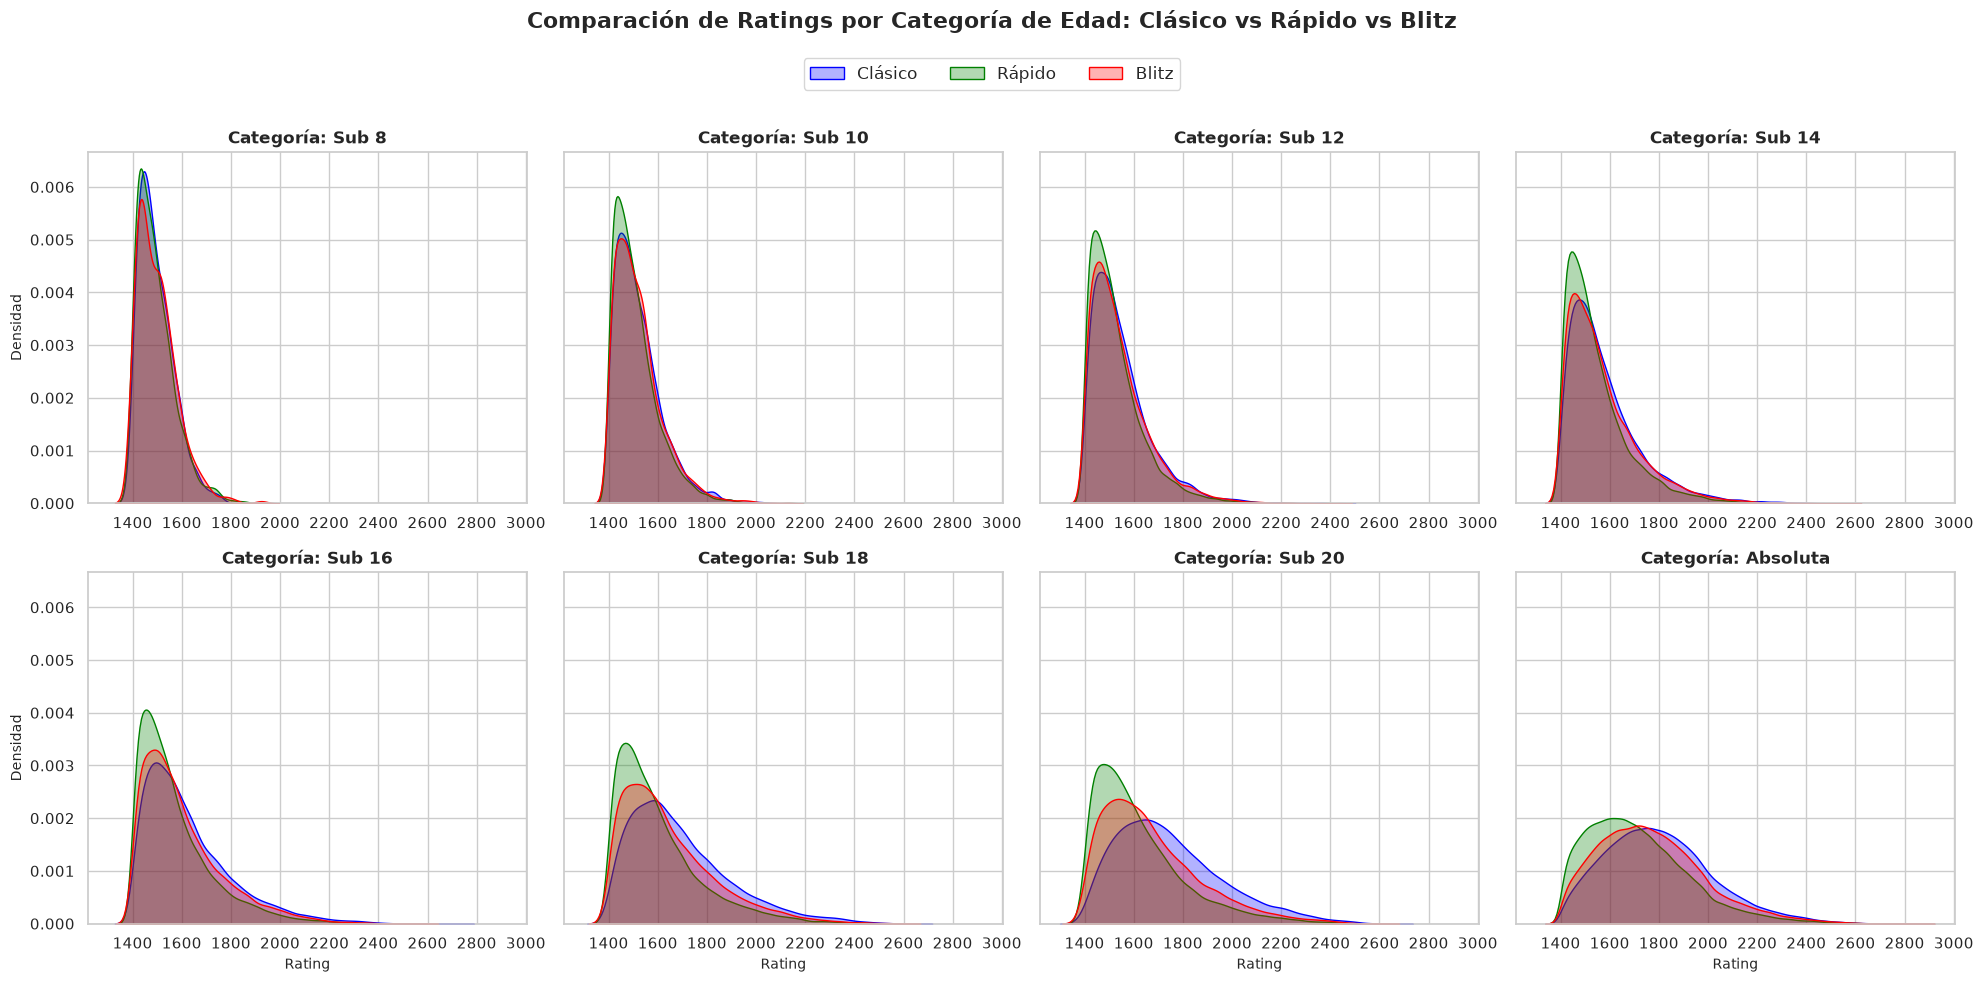

In [103]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()

categorias = list(reglas_ajedrez.keys())

for i, cat in enumerate(categorias):
    ax = axes[i]
    df_cat = df[df["categoria"] == cat]

    clasico = df_cat[df_cat["rating"] > 0]["rating"]
    rapido = df_cat[df_cat["rapid_rating"] > 0]["rapid_rating"]
    blitz = df_cat[df_cat["blitz_rating"] > 0]["blitz_rating"]

    if len(clasico) > 1 and clasico.nunique() > 1:
        sns.kdeplot(
            clasico, fill=True, color="blue", label="Clásico", ax=ax, alpha=0.3
        )
    if len(rapido) > 1 and rapido.nunique() > 1:
        sns.kdeplot(
            rapido, fill=True, color="green", label="Rápido", ax=ax, alpha=0.3
        )
    if len(blitz) > 1 and blitz.nunique() > 1:
        sns.kdeplot(
            blitz, fill=True, color="red", label="Blitz", ax=ax, alpha=0.3
        )

    ax.set_title(f"Categoría: {cat}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Rating", fontsize=10)
    ax.set_ylabel("Densidad", fontsize=10)
    ax.tick_params(labelbottom=True)

plt.suptitle(
    "Comparación de Ratings por Categoría de Edad: Clásico vs Rápido vs Blitz",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.94),
        ncol=3,
        fontsize=12,
    )

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### 1.5. Categorias Juveniles Segmentados por sexo

In [104]:
pd.crosstab(df['categoria'], df['sex']).reset_index()
genero = pd.crosstab(df['categoria'], df['sex']).reset_index()


df_categorias_seg = pd.merge(df_categorias, genero, on='categoria', how='left')



df_categorias_seg

,categoria,count,proporcion,porcentaje,F,M
0,Absoluta,266043,0.608563,60.86,14712,251331
1,Sub 16,40324,0.092240,9.22,6497,33827
2,Sub 18,36643,0.083819,8.38,5359,31284
3,Sub 14,34578,0.079096,7.91,6186,28392
4,Sub 20,28362,0.064877,6.49,3724,24638
5,Sub 12,22110,0.050576,5.06,4076,18034
6,Sub 10,8093,0.018512,1.85,1463,6630
7,Sub 8,1013,0.002317,0.23,180,833


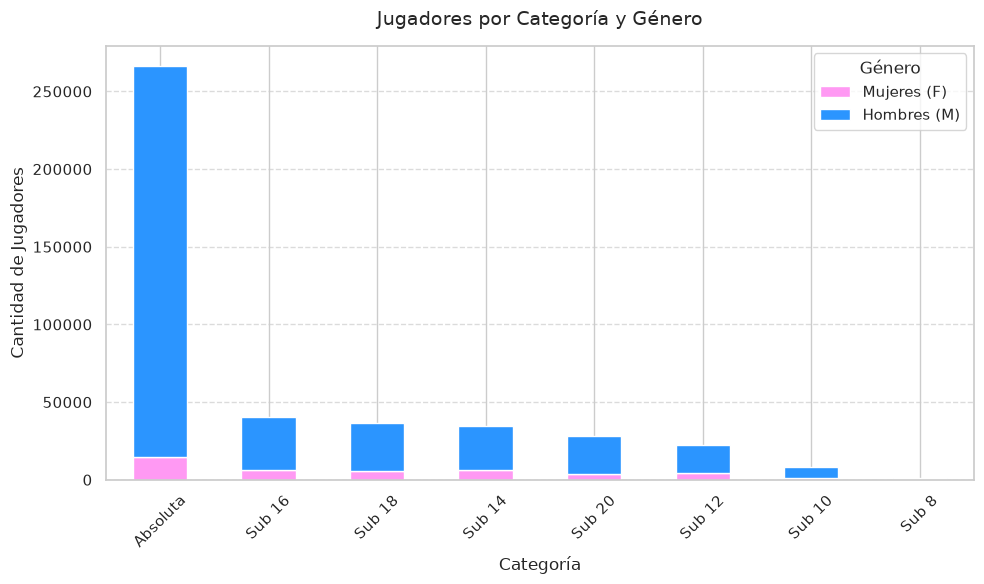

In [105]:

fig, ax = plt.subplots(figsize=(10, 6))

df_categorias_seg.set_index('categoria')[['F', 'M']].plot(
    kind='bar', 
    stacked=True, 
    color=["#ff99f3", "#2b95ff"], 
    ax=ax 
)

ax.set_title('Jugadores por Categoría y Género', fontsize=14, pad=15)
ax.set_xlabel('Categoría', fontsize=12)
ax.set_ylabel('Cantidad de Jugadores', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Género', labels=['Mujeres (F)', 'Hombres (M)'])
ax.grid(axis='y', linestyle='--', alpha=0.7)


fig.tight_layout()
plt.show()

### 1.6. Categorias Juveniles por Federacion. 

In [131]:
df_categoria_FED = (
    pd.crosstab(index=df['country'], columns=df['categoria'])
    .assign(total=lambda x: x.sum(axis=1))   
    .sort_values(by='total', ascending=False) 
    .reset_index()                            
)

orden = [
    'total',
    'Sub 8', 
    'Sub 10', 
    'Sub 12', 
    'Sub 14', 
    'Sub 16', 
    'Sub 18', 
    'Sub 20',
    'Absoluta',
    'country' 
]

df_categoria_FED = df_categoria_FED[orden[::-1]]
df_categoria_FED = df_categoria_FED.rename_axis(None, axis=1)

df_categoria_FED.head()

,country,Absoluta,Sub 20,Sub 18,Sub 16,Sub 14,Sub 12,Sub 10,Sub 8,total
0,IND,12643,2073,3601,6126,5583,3338,1340,277,34981
1,RUS,17906,2488,3668,3819,3423,2281,670,49,34304
2,FRA,21154,1707,2414,2654,2267,1524,521,40,32281
3,ESP,16402,1068,1326,1606,1305,791,265,29,22792
4,IRI,11612,1394,1899,1957,1720,1178,428,49,20237
